# E02. Evaluate Players
- This evaluates player projections
- Type: Evaluation
- Run Frequency: Irregular
- Sources:
    - Daily Fantasy Fuel
    - Player Results (MLB API)
- Created: 3/30/2024
- Updated: 8/5/2025

### Imports

In [1]:
# from DataImports import *
from U01Imports import *
from U02Functions import *

### Dates

In [2]:
start_date, end_date = "20250101", "20251231"
start_date, end_date = "20260101", "20261231"
# start_date, end_date = todaysdate, todaysdate

### Data

##### Games

Refresh game dataset

In [3]:
all_game_df = create_games(team_dict=team_dict, baseball_path=baseball_path, venue_map_df=venue_map_df, refresh_start_date=None, refresh_end_date=None)

Select games

In [4]:
game_df = all_game_df[(all_game_df['date'].astype(str) >= start_date) & (all_game_df['date'].astype(str) <= end_date)].reset_index(drop=True)

Filter out incomplete or shortened games

In [5]:
game_df = game_df[game_df['current_inning'] >= 9].reset_index(drop=True)  # Only completed games

##### Player Projections

In [6]:
def load_matchup_csvs_parallel(root_path, start_date, end_date, file_prefix):
    target_name = f"{file_prefix}.csv"
    s = int(start_date)
    e = int(end_date)

    # collect all file paths first (fast, single-threaded)
    file_paths = []

    for folder in os.listdir(root_path):
        if folder.startswith("Matchups "):
            date_str = folder.split("Matchups ")[1]
            if len(date_str) == 8 and date_str.isdigit():
                date_val = int(date_str)
                if s <= date_val <= e:
                    folder_path = os.path.join(root_path, folder)
                    for root, dirs, files in os.walk(folder_path):
                        if target_name in files:
                            file_paths.append(os.path.join(root, target_name))

    if not file_paths:
        return pd.DataFrame()

    # load CSVs in parallel
    dfs = Parallel(n_jobs=-1)(delayed(pd.read_csv)(fp) for fp in file_paths)

    return pd.concat(dfs, ignore_index=True)

Batters

In [7]:
%%time
batters_df  = load_matchup_csvs_parallel(os.path.join(baseball_path, "C01. Simulations", "2. Player Sims"), start_date, end_date, "batters") 

CPU times: total: 10.5 s
Wall time: 11.7 s


Pitchers

In [8]:
%%time
pitchers_df  = load_matchup_csvs_parallel(os.path.join(baseball_path, "C01. Simulations", "2. Player Sims"), start_date, end_date, "pitchers") 

CPU times: total: 14.5 s
Wall time: 15 s


##### Player Results

In [9]:
def load_player_results(root_path, game_df, prefixes):
    # prefixes example: ["away batters", "home batters"]
    game_ids = set(game_df["game_id"].astype(str).unique())

    file_paths = []

    # find all file paths
    for game_id in game_ids:
        folder_name = f"Player Results {game_id}"
        folder_path = os.path.join(root_path, folder_name)

        if not os.path.isdir(folder_path):
            continue

        for root, dirs, files in os.walk(folder_path):
            for f in files:
                for p in prefixes:
                    if f.startswith(p):
                        file_paths.append(os.path.join(root, f))
                        break

    if not file_paths:
        return pd.DataFrame()

    dfs = Parallel(n_jobs=-1)(
        delayed(pd.read_csv)(fp, encoding="iso-8859-1")
        for fp in file_paths
    )

    return pd.concat(dfs, ignore_index=True)


Batters

In [10]:
%%time
batter_results_df = load_player_results(os.path.join(baseball_path, "A01. Player Results"), game_df, prefixes=["away batters", "home batters"])

CPU times: total: 1.38 s
Wall time: 2.2 s


Pitchers

In [11]:
%%time
pitcher_results_df = load_player_results(os.path.join(baseball_path, "A01. Player Results"), game_df, prefixes=["away pitchers", "home pitchers"])

CPU times: total: 750 ms
Wall time: 1.11 s


##### DFF Projections

DFF - Date-Based

DFF projections from when I extracted only one set of projections per day

In [12]:
# Set the directory path
directory = os.path.join(baseball_path, "A08. Projections", "1. DFF", "2. Projections", "Date")

# Initialize an empty list to store dataframes
dfs = []

# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Check if the file is a CSV file
        # Read the CSV file into a pandas dataframe
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath, dtype='str')
        dfs.append(df)  # Append the dataframe to the list

# Concatenate all dataframes into a single dataframe
dff_date_df = pd.concat(dfs, ignore_index=True)

# Drop duplicates based on "First Name", "Last Name", and "date"
dff_date_df.drop_duplicates(subset=["first_name", "last_name", "game_date"], inplace=True)

# Print the resulting dataframe
print(dff_date_df.shape)

(40795, 22)


DFF - Slate-Based

DFF projections from when I extract one set of projections per slate

In [13]:
# Set the directory path
directory = os.path.join(baseball_path, "A08. Projections", "1. DFF", "2. Projections")


# Initialize an empty list to store dataframes
dfs = []

# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Check if the file is a CSV file
        # Read the CSV file into a pandas dataframe
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath, dtype='str')
        dfs.append(df)  # Append the dataframe to the list

# Concatenate all dataframes into a single dataframe
dff_slate_df = pd.concat(dfs, ignore_index=True)

# Drop duplicates based on "First Name", "Last Name", and "date"
dff_slate_df.drop_duplicates(subset=["First Name", "Last Name", "date"], inplace=True)

# Print the resulting dataframe
print(dff_slate_df.shape)

(153391, 22)


### Clean

In [14]:
woba_weights = {'b1': 0.882, 'b2': 1.254, 'b3': 1.590, 'hr': 2.050, 'bb': 0.689, 'hbp': 0.720}

##### Batter Sim Results

Calculate missing fields

In [15]:
batters_df['H'] = batters_df[['B1', 'B2', 'B3', 'HR']].sum(axis=1)
batters_df['ON'] = batters_df[['H', 'BB', 'HBP']].sum(axis=1)
batters_df['wOBA'] = (batters_df['B1'] * woba_weights['b1'] +
                      batters_df['B2'] * woba_weights['b2'] +
                      batters_df['B3'] * woba_weights['b3'] +
                      batters_df['HR'] * woba_weights['hr'] +
                      batters_df['BB'] * woba_weights['bb'] +
                      batters_df['HBP'] * woba_weights['hbp'])

##### Batter Actual Results

Calculate missing fields

In [16]:
batter_results_df['B1'] = batter_results_df['h'] - batter_results_df['doubles'] - batter_results_df['triples'] - batter_results_df['hr']
batter_results_df['PA'] = batter_results_df[['ab', 'bb', 'hbp']].sum(axis=1)
batter_results_df['ON'] = batter_results_df[['h', 'bb', 'hbp']].sum(axis=1)
batter_results_df['wOBA'] = (batter_results_df['B1'] * woba_weights['b1'] +
                             batter_results_df['doubles'] * woba_weights['b2'] +
                             batter_results_df['triples'] * woba_weights['b3'] +
                             batter_results_df['hr'] * woba_weights['hr'] +
                             batter_results_df['bb'] * woba_weights['bb'] +
                             batter_results_df['hbp'] * woba_weights['hbp'])

In [17]:
# Spot in batting order
batter_results_df['battingSpot'] = batter_results_df['battingOrder'] // 100
# Instance of batter in that spot
# battingSpotInstance for starter would be 1, the first sub would be 2, second sub would be 3
batter_results_df['battingSpotInstance'] = (batter_results_df.groupby(['gamePk', 'team', 'battingSpot']).cumcount() + 1)
batter_results_df['unsubbedBatter'] = (batter_results_df.groupby(['gamePk', 'team', 'battingSpot'])['battingSpot'].transform('size').eq(1).astype(int))

Rename to match sim columns

In [18]:
batter_results_df.rename(columns={'singles': 'B1',
                                  'doubles': 'B2',
                                  'triples': 'B3',
                                  'hr': 'HR',
                                  'bb': 'BB',
                                  'hbp': 'HBP',
                                  'sb': 'SB',
                                  'h': 'H',
                                  'r': 'R',
                                  'rbi': 'RBI',
                                  'fp': 'FP',
                                  'personId': 'id',
                                  'gamePk': 'game_id'}, inplace=True)

##### Pitcher Sim Results

Rename to match sim columns

In [19]:
pitcher_results_df.rename(columns={'pa': 'PA',
                                   'outs': 'OUT',
                                   'er': 'ER',
                                   'r': 'R',
                                   'h': 'H',
                                   'k': 'SO',
                                   'w': 'W',
                                   'fp': 'FP',
                                   'personId': 'id',
                                   'gamePk': 'game_id'}, inplace=True)

##### DFF Projections

Clean name and date

In [20]:
dff_date_df.rename(columns={'first_name':'First Name', 'last_name':'Last Name', 'ppg_projection':'FP', 'team':'Team'}, inplace=True)
dff_date_df['date'] = dff_date_df['game_date'].str.replace("-", "").astype('int')

Combine DFF dataframes

In [21]:
dff_df = pd.concat([dff_date_df[['First Name', 'Last Name', 'Team', 'FP', 'date']], dff_slate_df[['First Name', 'Last Name', 'FP', 'Team', 'date']]], axis=0)

Clean name

In [22]:
dff_df['fullName'] = dff_df['First Name'] + " " + dff_df['Last Name']
dff_df.rename(columns={'FP': 'FP_DFF'}, inplace=True)

Only keep one instance per player per game

Note: doubleheaders could be confused here - currently dropping both

In [23]:
dff_df = dff_df.drop_duplicates(subset=['fullName', 'date', 'FP_DFF'])

Format data types

In [24]:
dff_df['FP_DFF'] = dff_df['FP_DFF'].astype('float')
dff_df['date'] = pd.to_numeric(dff_df['date'], errors='coerce')

##### Batters

In [25]:
# Merge simulation results with actual player results
batter_dataset = pd.merge(batters_df[batters_df['sim'] < 500], batter_results_df.drop(columns=['team', 'teamabbrev', 'name', 'date', 'substitution']), on=['game_id', 'id'], suffixes=('_pred', '_act'), how='left')
# Merge with actual scores
batter_dataset = pd.merge(batter_dataset, game_df[['game_id', 'venue_name', 'date', 'away_team', 'home_team', 'away_score', 'home_score']], on=['game_id'], how='left', suffixes=('_proj', ""))
# Merge with DFF projections
batter_dataset = pd.merge(batter_dataset, dff_df[['fullName', 'date', 'FP_DFF']], on=['fullName', 'date'], how='left')

### Merge

##### Pitchers

In [26]:
# Merge simulation results with actual player results
pitcher_dataset = pd.merge(pitchers_df[pitchers_df['sim'] < 500], pitcher_results_df.drop(columns=['team', 'name', 'date']), on=['game_id', 'id'], suffixes=('_pred', '_act'), how='left')
# Merge with actual scores
pitcher_dataset = pd.merge(pitcher_dataset, game_df[['game_id', 'venue_name', 'date', 'away_team', 'home_team', 'away_score', 'home_score']], on=['game_id'], how='left', suffixes=('_proj', ""))
# Merge with projections
pitcher_dataset = pd.merge(pitcher_dataset, dff_df[['fullName', 'date', 'FP_DFF']], on=['fullName', 'date'], how='left')

### 1. Team Stat Evaluations

##### 1A. Batters

In [27]:
batter_stat_list = ['PA','ON','B1','B2','B3','HR','BB','HBP','R','RBI','SB','wOBA','FP']

In [28]:
# Override actual PA
# This is impossible to calculate using the results data. You can get close, but certain things do not appear in the box score.
# You can get the actual value from pitchers
actual_pa_override = pitcher_results_df.groupby(['game_id', 'team']).sum()[['PA']].mean()
# Note: HBP might be slightly underreported as well.


# Get means
sim_mean = (
    batters_df
    .groupby(['game_id', 'sim', 'team'])
    .sum()[batter_stat_list]
    .mean()
)

act_mean = (
    batter_results_df
    .groupby(['game_id','team'])
    .sum()[batter_stat_list]
    .mean()
)

# Align names
act_mean.index = sim_mean.index

# Apply override
if actual_pa_override is not None:
    act_mean['PA'] = actual_pa_override

# Build dataframe
df = pd.DataFrame({
    'Stat': sim_mean.index,
    'Projection': sim_mean.values,
    'Actual': act_mean.values,
})

# Per-PA
df['Projection%'] = df['Projection'] / sim_mean['PA']
df['Actual%'] = df['Actual'] / act_mean['PA']

# Fix PA row
df.loc[df['Stat'] == 'PA', ['Projection%', 'Actual%']] = 1

df

,Stat,Projection,Actual,Projection%,Actual%
0,PA,38.556474,37.802498,1.000000,1.000000
1,ON,12.406569,11.996487,0.321777,0.317346
2,B1,5.528967,5.333333,0.143399,0.141084
3,B2,1.653598,1.571429,0.042888,0.041569
4,B3,0.151843,0.131538,0.003938,0.003480
5,HR,1.083550,1.141686,0.028103,0.030201
6,BB,3.530420,3.413349,0.091565,0.090294
7,HBP,0.458192,0.405152,0.011884,0.010718
8,R,4.529507,4.494926,0.117477,0.118906
9,RBI,4.342574,4.304450,0.112629,0.113867


##### 1B. Pitchers

In [29]:
pitcher_stat_list = ['PA','OUT','ER','R','H','SO','W','FP']

In [30]:
# Override actual PA
# This should be unnecessary for pitchers as their PA is provided by the MLB API
actual_pa_override = None


# Get means
sim_mean = (
    pitchers_df
    .groupby(['game_id', 'sim', 'team'])
    .sum()[pitcher_stat_list]
    .mean()
)

act_mean = (
    pitcher_results_df
    .groupby(['game_id','team'])
    .sum()[pitcher_stat_list]
    .mean()
)

# Align names
act_mean.index = sim_mean.index

# Apply override
if actual_pa_override is not None:
    act_mean['PA'] = actual_pa_override

# Build dataframe
df = pd.DataFrame({
    'Stat': sim_mean.index,
    'Projection': sim_mean.values,
    'Actual': act_mean.values,
})

# Per-PA
df['Projection%'] = df['Projection'] / sim_mean['PA']
df['Actual%'] = df['Actual'] / act_mean['PA']

# Fix PA row
df.loc[df['Stat'] == 'PA', ['Projection%', 'Actual%']] = 1

df

,Stat,Projection,Actual,Projection%,Actual%
0,PA,38.556474,37.802498,1.000000,1.000000
1,OUT,26.953686,26.594848,0.699070,0.703521
2,ER,4.077793,4.138173,0.105762,0.109468
3,R,4.529507,4.494926,0.117477,0.118906
4,H,8.417957,8.177986,0.218328,0.216335
5,SO,8.617006,8.365730,0.223491,0.221301
6,W,0.504779,0.500000,0.013092,0.013227
7,FP,23.882121,23.218970,0.619406,0.614218


### 2. Player Stat Evaluations

In [31]:
def build_stat_comparison(df, stat_list):
    rows = []

    pa_pred = df['PA_pred'].sum()
    pa_act  = df['PA_act'].sum()

    for s in stat_list:
        pred_mean = df[f'{s}_pred'].mean()
        act_mean  = df[f'{s}_act'].mean()

        pred_pct = df[f'{s}_pred'].sum() / pa_pred if pa_pred != 0 else None
        act_pct  = df[f'{s}_act'].sum() / pa_act  if pa_act  != 0 else None

        rows.append({
            'Stat': s,
            'Projection': pred_mean,
            'Actual': act_mean,
            'Projection%': pred_pct,
            'Actual%': act_pct
        })

    return pd.DataFrame(rows)

##### 2A. Starting Batters

In [32]:
build_stat_comparison(batter_dataset[(batter_dataset['battingSpotInstance'] == 1) & (batter_dataset['unsubbedBatter'] == 1)].groupby(['game_id', 'id']).mean(numeric_only=True), batter_stat_list)

,Stat,Projection,Actual,Projection%,Actual%
0,PA,4.254809,4.155056,1.000000,1.000000
1,ON,1.371381,1.336894,0.322313,0.321751
2,B1,0.612061,0.591796,0.143851,0.142428
3,B2,0.182337,0.176843,0.042854,0.042561
4,B3,0.016658,0.014719,0.003915,0.003542
5,HR,0.119350,0.130188,0.028051,0.031332
6,BB,0.390636,0.380360,0.091810,0.091542
7,HBP,0.050340,0.042988,0.011831,0.010346
8,R,0.499766,0.501621,0.117459,0.120725
9,RBI,0.478349,0.478453,0.112426,0.115149


##### 2B. Unimputed Starting Batters

In [33]:
build_stat_comparison(batter_dataset.query('imp_b_l == 0 & imp_b_r == 0')[(batter_dataset['battingSpotInstance'] == 1) & (batter_dataset['unsubbedBatter'] == 1)].groupby(['game_id', 'id']).mean(numeric_only=True), batter_stat_list)

,Stat,Projection,Actual,Projection%,Actual%
0,PA,4.272751,4.175215,1.000000,1.000000
1,ON,1.383939,1.344452,0.323899,0.322008
2,B1,0.616545,0.593059,0.144297,0.142043
3,B2,0.184192,0.176681,0.043108,0.042317
4,B3,0.016712,0.014655,0.003911,0.003510
5,HR,0.121337,0.132306,0.028398,0.031688
6,BB,0.394526,0.384137,0.092335,0.092004
7,HBP,0.050627,0.043613,0.011849,0.010446
8,R,0.505097,0.506888,0.118214,0.121404
9,RBI,0.483048,0.478516,0.113053,0.114609


##### 2C. Imputed Starting Batters

In [34]:
build_stat_comparison(batter_dataset.query('imp_b_l == 1 | imp_b_r == 1')[(batter_dataset['battingSpotInstance'] == 1) & (batter_dataset['unsubbedBatter'] == 1)].groupby(['game_id', 'id']).mean(numeric_only=True), batter_stat_list)

,Stat,Projection,Actual,Projection%,Actual%
0,PA,4.080902,3.959659,1.000000,1.000000
1,ON,1.249660,1.263636,0.306221,0.319128
2,B1,0.568592,0.579545,0.139330,0.146362
3,B2,0.164355,0.178409,0.040274,0.045057
4,B3,0.016131,0.015341,0.003953,0.003874
5,HR,0.100095,0.109659,0.024528,0.027694
6,BB,0.352928,0.343750,0.086483,0.086813
7,HBP,0.047559,0.036932,0.011654,0.009327
8,R,0.448098,0.450568,0.109804,0.113790
9,RBI,0.432805,0.477841,0.106056,0.120677


##### 2D. Starting Pitchers

In [35]:
build_stat_comparison(pitcher_dataset[(pitcher_dataset['starter'] == 1)].groupby(['game_id', 'id']).mean(numeric_only=True), pitcher_stat_list)

,Stat,Projection,Actual,Projection%,Actual%
0,PA,21.682405,21.665586,1.000000,1.000000
1,OUT,15.195479,15.310373,0.700821,0.706954
2,ER,2.354782,2.405592,0.108603,0.111078
3,R,2.564516,2.564019,0.118276,0.118393
4,H,4.848043,4.762561,0.223593,0.219911
5,SO,4.756200,4.755267,0.219358,0.219574
6,W,0.286849,0.297002,0.013230,0.013714
7,FP,13.211145,13.313006,0.609303,0.614726


##### 2E. Unimputed Starting Pitchers

In [36]:
build_stat_comparison(pitcher_dataset.query('imp_p_l == 0 & imp_p_r == 0')[(pitcher_dataset['starter'] == 1)].groupby(['game_id', 'id']).mean(numeric_only=True), pitcher_stat_list)

,Stat,Projection,Actual,Projection%,Actual%
0,PA,21.788732,21.742290,1.000000,1.000000
1,OUT,15.286255,15.381757,0.701567,0.707757
2,ER,2.357688,2.402872,0.108207,0.110563
3,R,2.567674,2.562500,0.117844,0.117908
4,H,4.869076,4.781672,0.223468,0.220018
5,SO,4.795160,4.790963,0.220075,0.220445
6,W,0.290071,0.301098,0.013313,0.013854
7,FP,13.354811,13.459206,0.612923,0.619295


##### 2F. Imputed Starting Pitchers

In [37]:
build_stat_comparison(pitcher_dataset.query('imp_p_l == 1 | imp_p_r == 1')[(pitcher_dataset['starter'] == 1)].groupby(['game_id', 'id']).mean(numeric_only=True), pitcher_stat_list)

,Stat,Projection,Actual,Projection%,Actual%
0,PA,19.164580,19.850000,1.000000,1.000000
1,OUT,13.045880,13.620000,0.680729,0.686146
2,ER,2.285960,2.470000,0.119280,0.124433
3,R,2.489720,2.600000,0.129913,0.130982
4,H,4.349960,4.310000,0.226979,0.217128
5,SO,3.833620,3.910000,0.200037,0.196977
6,W,0.210540,0.200000,0.010986,0.010076
7,FP,9.809138,9.851000,0.511837,0.496272


### 3. Competitor Projection Evaluations

Compare my simulated projections to other source(s) of player fantasy point projections

##### 3A. Batter FP Distributions

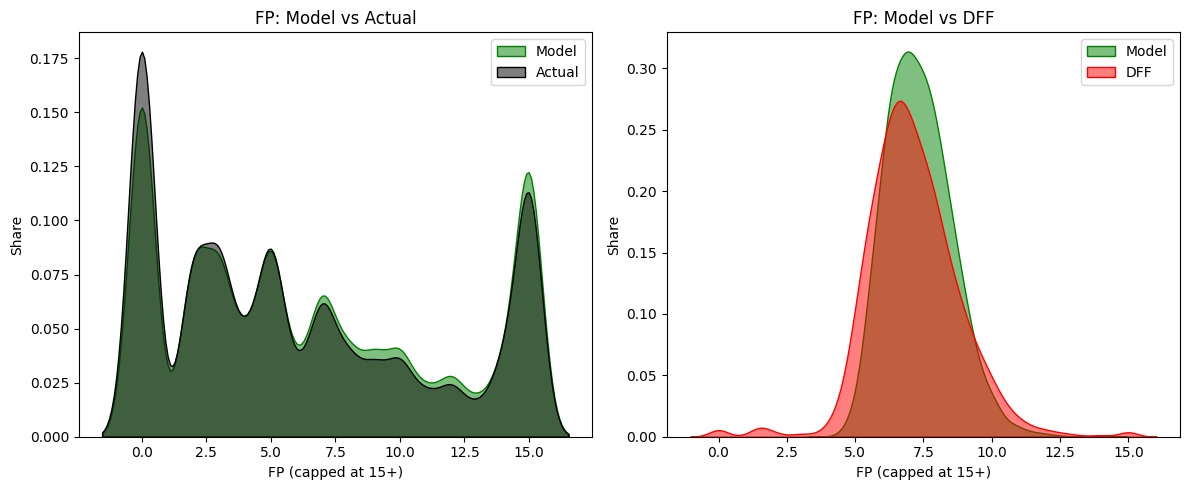

CPU times: total: 1min 2s
Wall time: 1min 2s


In [38]:
%%time
# Cap FP values at 15+
FP_capped = np.minimum(batter_dataset.query('battingSpotInstance == 1')['FP_pred'], 15)
fp_capped = np.minimum(batter_dataset.query('battingSpotInstance == 1')['FP_act'], 15)

plt.figure(figsize=(12, 5))

# Histogram 1: FP vs fp (Model vs Actual)
plt.subplot(1, 2, 1)
sns.kdeplot(FP_capped, fill=True, color='green', alpha=0.5, label='Model', bw_adjust=2.5)
sns.kdeplot(fp_capped, fill=True, color='black', alpha=0.5, label='Actual', bw_adjust=2.5)
plt.xlabel('FP (capped at 15+)')
plt.ylabel('Share')
plt.title('FP: Model vs Actual')
plt.legend()

# Histogram 2: FP vs FP_DFF (grouped, capped)
grouped = batter_dataset.groupby(['game_id', 'id']).mean(numeric_only=True).reset_index()
FP_grouped_capped = np.minimum(grouped['FP_pred'], 15)
FP_DFF_capped = np.minimum(grouped['FP_DFF'], 15)

plt.subplot(1, 2, 2)
sns.kdeplot(FP_grouped_capped, fill=True, color='green', alpha=0.5, label='Model', bw_adjust=1.5)
sns.kdeplot(FP_DFF_capped, fill=True, color='red', alpha=0.5, label='DFF', bw_adjust=1.5)
plt.xlabel('FP (capped at 15+)')
plt.ylabel('Share')
plt.title('FP: Model vs DFF')
plt.legend()

plt.tight_layout()
plt.show()

##### 3B. Pitcher FP Distributions

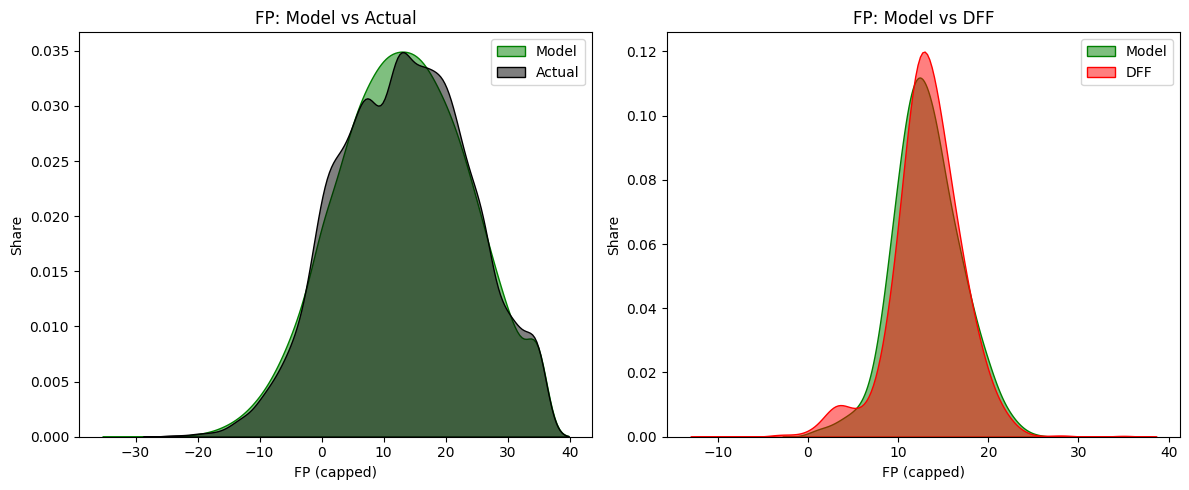

CPU times: total: 7.61 s
Wall time: 7.65 s


In [39]:
%%time
# Cap FP values
FP_capped = np.minimum(pitcher_dataset.query('starter == 1')['FP_pred'], 35)
fp_capped = np.minimum(pitcher_dataset.query('starter == 1')['FP_act'], 35)

plt.figure(figsize=(12, 5))

# Histogram 1: FP vs fp (Model vs Actual)
plt.subplot(1, 2, 1)
sns.kdeplot(FP_capped, fill=True, color='green', alpha=0.5, label='Model', bw_adjust=2.5)
sns.kdeplot(fp_capped, fill=True, color='black', alpha=0.5, label='Actual', bw_adjust=2.5)
plt.xlabel('FP (capped)')
plt.ylabel('Share')
plt.title('FP: Model vs Actual')
plt.legend()

# Histogram 2: FP vs FP_DFF (grouped, capped)
grouped = pitcher_dataset.query('starter == 1').groupby(['game_id', 'id']).mean(numeric_only=True).reset_index()
FP_grouped_capped = np.minimum(grouped['FP_pred'], 35)
FP_DFF_capped = np.minimum(grouped['FP_DFF'], 35)

plt.subplot(1, 2, 2)
sns.kdeplot(FP_grouped_capped, fill=True, color='green', alpha=0.5, label='Model', bw_adjust=1.5)
sns.kdeplot(FP_DFF_capped, fill=True, color='red', alpha=0.5, label='DFF', bw_adjust=1.5)
plt.xlabel('FP (capped)')
plt.ylabel('Share')
plt.title('FP: Model vs DFF')
plt.legend()

plt.tight_layout()
plt.show()

##### 3C. Batter FP over Time

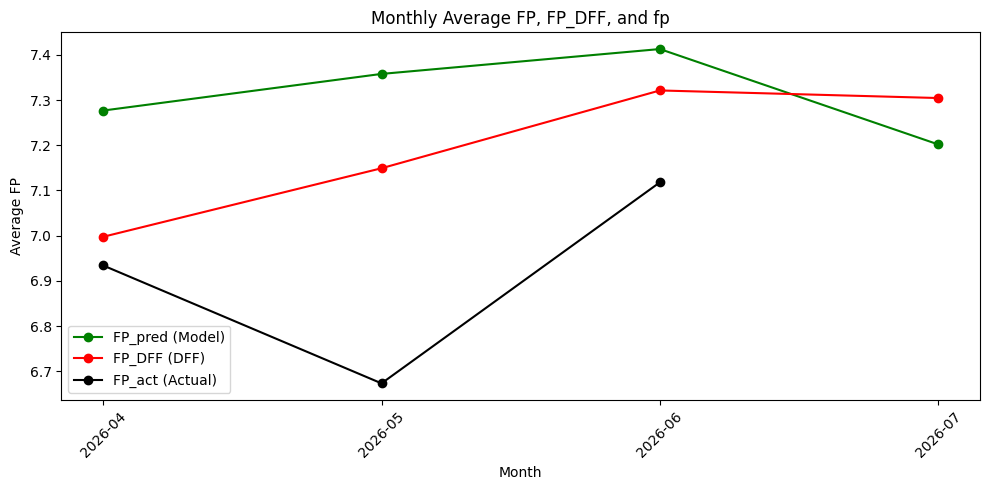

In [40]:
# Convert YYYYMMDD to datetime
batter_dataset['date'] = pd.to_datetime(batter_dataset['date'], format='%Y%m%d', errors='coerce')

# Drop any rows with invalid dates
batter_dataset = batter_dataset.dropna(subset=['date'])

# Filter months April (4) through September (9)
mask = batter_dataset['date'].dt.month.between(4, 9)
batter_filtered = batter_dataset[mask].copy()

# Create 'month' column (year-month)
batter_filtered['month'] = batter_filtered['date'].dt.to_period('M')

# Group by month and compute averages
batter_monthly_avg = batter_filtered.groupby('month')[['FP_pred', 'FP_DFF', 'FP_act']].mean().reset_index()

# Convert 'month' to string for plotting
batter_monthly_avg['month'] = batter_monthly_avg['month'].astype(str)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(batter_monthly_avg['month'], batter_monthly_avg['FP_pred'], marker='o', color='green', label='FP_pred (Model)')
plt.plot(batter_monthly_avg['month'], batter_monthly_avg['FP_DFF'], marker='o', color='red', label='FP_DFF (DFF)')
plt.plot(batter_monthly_avg['month'], batter_monthly_avg['FP_act'], marker='o', color='black', label='FP_act (Actual)')

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average FP')
plt.title('Monthly Average FP, FP_DFF, and fp')
plt.legend()
plt.tight_layout()
plt.show()

##### 3D. Pitcher FP over Time

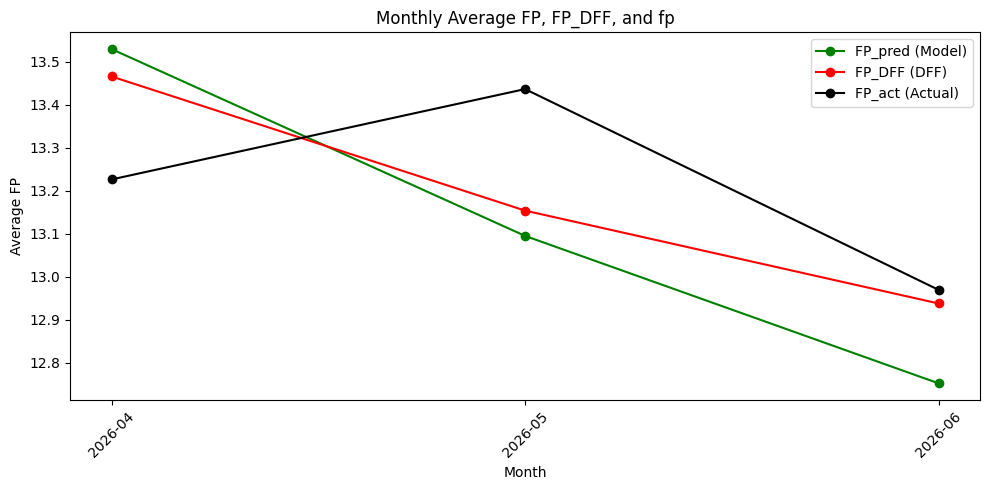

In [41]:
# Convert YYYYMMDD to datetime
pitcher_dataset['date'] = pd.to_datetime(pitcher_dataset['date'], format='%Y%m%d', errors='coerce')

# Drop any rows with invalid dates
# pitcher_dataset = pitcher_dataset.query('starter == 1').dropna(subset=['date'])

# Filter months April (4) through September (9)
mask = pitcher_dataset['date'].dt.month.between(4, 9)
pitcher_filtered = pitcher_dataset.query('starter == 1')[mask].copy()

# Create 'month' column (year-month)
pitcher_filtered['month'] = pitcher_filtered['date'].dt.to_period('M')

# Group by month and compute averages
pitcher_monthly_avg = pitcher_filtered.groupby('month')[['FP_pred', 'FP_DFF', 'FP_act']].mean().reset_index()

# Convert 'month' to string for plotting
pitcher_monthly_avg['month'] = pitcher_monthly_avg['month'].astype(str)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(pitcher_monthly_avg['month'], pitcher_monthly_avg['FP_pred'], marker='o', color='green', label='FP_pred (Model)')
plt.plot(pitcher_monthly_avg['month'], pitcher_monthly_avg['FP_DFF'], marker='o', color='red', label='FP_DFF (DFF)')
plt.plot(pitcher_monthly_avg['month'], pitcher_monthly_avg['FP_act'], marker='o', color='black', label='FP_act (Actual)')

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average FP')
plt.title('Monthly Average FP, FP_DFF, and fp')
plt.legend()
plt.tight_layout()
plt.show()

##### 3E. Batters by Venue

In [42]:
# Step 1: Group by game_id, id, venue_id, venue_name
grouped_players = batter_dataset.query('battingSpotInstance == 1').groupby(['game_id', 'id', 'venue_id', 'venue_name']).mean(numeric_only=True).reset_index()

# Step 2: Venue-level aggregation
venue_avg = grouped_players.groupby(['venue_id', 'venue_name']).agg(
    FP_pred=('FP_pred', 'mean'),
    FP_DFF=('FP_DFF', 'mean'),
    FP_act=('FP_act', 'mean'),
    count=('game_id', 'count')
).reset_index()

# Convert venue_id to int
venue_avg['venue_id'] = venue_avg['venue_id'].astype(int)

# Step 3: Filter venues with enough data
venue_avg_filtered = venue_avg[venue_avg['count'] > 000].copy()

# Step 4: Compute differences
venue_avg_filtered['FP_diff'] = venue_avg_filtered['FP_pred'] - venue_avg_filtered['FP_act']
venue_avg_filtered['FP_DFF_diff'] = venue_avg_filtered['FP_DFF'] - venue_avg_filtered['FP_act']

# Step 5: Add total/average row
total_row = pd.DataFrame({
    'venue_id': [0],
    'venue_name': ['TOTAL'],
    'FP_pred': [venue_avg_filtered['FP_pred'].mean()],
    'FP_DFF': [venue_avg_filtered['FP_DFF'].mean()],
    'FP_act': [venue_avg_filtered['FP_act'].mean()],
    'count': [venue_avg_filtered['count'].sum()],
    'FP_diff': [venue_avg_filtered['FP_diff'].mean()],
    'FP_DFF_diff': [venue_avg_filtered['FP_DFF_diff'].mean()]
})

# Step 6: Add MSE row
mse_row = pd.DataFrame({
    'venue_id': [np.nan],
    'venue_name': ['MSE'],
    'FP_pred': [(venue_avg_filtered['FP_diff'] ** 2).mean()],
    'FP_DFF': [(venue_avg_filtered['FP_DFF_diff'] ** 2).mean()],
    'FP_act': [np.nan],
    'count': [np.nan],
    'FP_diff': [np.nan],
    'FP_DFF_diff': [np.nan]
})

venue_avg_final = pd.concat([venue_avg_filtered, total_row, mse_row], ignore_index=True)

# Step 7: Bold + gold background for closer value
def style_closer(row):

    # Handle MSE row
    if row['venue_name'] == 'MSE':
        fp_mse = row['FP_pred']
        dff_mse = row['FP_DFF']

        styles = {}
        if fp_mse < dff_mse:
            styles['FP_pred'] = 'font-weight: bold; background-color: gold'
            styles['FP_DFF'] = ''
        elif dff_mse < fp_mse:
            styles['FP_pred'] = ''
            styles['FP_DFF'] = 'font-weight: bold; background-color: gold'
        else:
            styles['FP_pred'] = ''
            styles['FP_DFF'] = ''

        return pd.Series(styles)

    # Skip TOTAL row
    if pd.isna(row['FP_act']):
        return pd.Series({'FP_pred': '', 'FP_DFF': ''})

    fp_val = row['FP_act']

    fp_dist = abs(row['FP_pred'] - fp_val)
    dff_dist = abs(row['FP_DFF'] - fp_val)

    styles = {}
    if fp_dist < dff_dist:
        styles['FP_pred'] = 'font-weight: bold; background-color: gold'
        styles['FP_DFF'] = ''
    elif dff_dist < fp_dist:
        styles['FP_pred'] = ''
        styles['FP_DFF'] = 'font-weight: bold; background-color: gold'
    else:
        styles['FP_pred'] = ''
        styles['FP_DFF'] = ''

    return pd.Series(styles)

# Step 8: Color function for diff columns
def color_diff(val):

    if pd.isna(val):
        return ''

    max_val = 2
    percent = min(abs(val) / max_val, 1) * 50

    if val > 0:
        return f"""
            background: linear-gradient(to right, transparent 50%, red 50%, red {50 + percent}%, transparent {50 + percent}%);
            color: black;
        """
    elif val < 0:
        return f"""
            background: linear-gradient(to left, transparent 50%, blue 50%, blue {50 + percent}%, transparent {50 + percent}%);
            color: black;
        """
    else:
        return ''

# Step 9: Apply styling
styler = venue_avg_final.style.apply(style_closer, axis=1)
styler = styler.applymap(color_diff, subset=['FP_diff', 'FP_DFF_diff'])

# Step 10: Format numbers
styler = styler.format({
    'venue_id': '{:.0f}',
    'FP_pred': '{:.2f}',
    'FP_DFF': '{:.2f}',
    'FP_act': '{:.2f}',
    'FP_diff': '{:.2f}',
    'FP_DFF_diff': '{:.2f}',
    'count': '{:.0f}'
})

styler

,venue_id,venue_name,FP_pred,FP_DFF,FP_act,count,FP_diff,FP_DFF_diff
0,1,Angel Stadium,7.43,7.20,6.57,731,0.86,0.63
1,2,Oriole Park at Camden Yards,7.27,7.25,7.14,782,0.12,0.11
2,3,Fenway Park,7.02,6.90,6.33,735,0.69,0.57
3,4,Rate Field,7.30,7.12,6.72,702,0.58,0.40
4,5,Progressive Field,7.17,6.66,6.37,699,0.80,0.29
5,7,Kauffman Stadium,7.75,7.21,7.44,720,0.31,-0.23
6,12,Tropicana Field,7.30,6.91,7.07,727,0.23,-0.16
7,14,Rogers Centre,6.91,6.98,6.70,824,0.21,0.28
8,15,Chase Field,7.76,7.26,6.82,730,0.94,0.43
9,17,Wrigley Field,7.65,7.27,7.06,752,0.59,0.21


##### 3F. Pitchers by Venue

In [43]:
# Step 1: Group by game_id, id, venue_id, venue_name
grouped_pitchers = pitcher_dataset.query('starter == 1').groupby(['game_id', 'id', 'venue_id', 'venue_name']).mean(numeric_only=True).reset_index()

# Step 2: Venue-level aggregation
venue_avg = grouped_pitchers.groupby(['venue_id', 'venue_name']).agg(
    FP_pred=('FP_pred', 'mean'),
    FP_DFF=('FP_DFF', 'mean'),
    FP_act=('FP_act', 'mean'),
    count=('game_id', 'count')
).reset_index()

# Convert venue_id to int
venue_avg['venue_id'] = venue_avg['venue_id'].astype(int)

# Step 3: Filter venues with enough data
venue_avg_filtered = venue_avg[venue_avg['count'] > 00].copy()

# Step 4: Compute differences
venue_avg_filtered['FP_diff'] = venue_avg_filtered['FP_pred'] - venue_avg_filtered['FP_act']
venue_avg_filtered['FP_DFF_diff'] = venue_avg_filtered['FP_DFF'] - venue_avg_filtered['FP_act']

# Step 5: Add total/average row
total_row = pd.DataFrame({
    'venue_id': [0],
    'venue_name': ['TOTAL'],
    'FP_pred': [venue_avg_filtered['FP_pred'].mean()],
    'FP_DFF': [venue_avg_filtered['FP_DFF'].mean()],
    'FP_act': [venue_avg_filtered['FP_act'].mean()],
    'count': [venue_avg_filtered['count'].sum()],
    'FP_diff': [venue_avg_filtered['FP_diff'].mean()],
    'FP_DFF_diff': [venue_avg_filtered['FP_DFF_diff'].mean()]
})

# Step 6: Add MSE row
mse_row = pd.DataFrame({
    'venue_id': [np.nan],
    'venue_name': ['MSE'],
    'FP_pred': [(venue_avg_filtered['FP_diff'] ** 2).mean()],
    'FP_DFF': [(venue_avg_filtered['FP_DFF_diff'] ** 2).mean()],
    'FP_act': [np.nan],
    'count': [np.nan],
    'FP_diff': [np.nan],
    'FP_DFF_diff': [np.nan]
})

venue_avg_final = pd.concat([venue_avg_filtered, total_row, mse_row], ignore_index=True)

def style_closer(row):

    # Handle MSE row
    if row['venue_name'] == 'MSE':
        fp_mse = row['FP_pred']
        dff_mse = row['FP_DFF']

        styles = {}
        if fp_mse < dff_mse:
            styles['FP_pred'] = 'font-weight: bold; background-color: gold'
            styles['FP_DFF'] = ''
        elif dff_mse < fp_mse:
            styles['FP_pred'] = ''
            styles['FP_DFF'] = 'font-weight: bold; background-color: gold'
        else:
            styles['FP_pred'] = ''
            styles['FP_DFF'] = ''

        return pd.Series(styles)

    # Skip TOTAL row
    if pd.isna(row['FP_act']):
        return pd.Series({'FP_pred': '', 'FP_DFF': ''})

    fp_val = row['FP_act']

    fp_dist = abs(row['FP_pred'] - fp_val)
    dff_dist = abs(row['FP_DFF'] - fp_val)

    styles = {}
    if fp_dist < dff_dist:
        styles['FP_pred'] = 'font-weight: bold; background-color: gold'
        styles['FP_DFF'] = ''
    elif dff_dist < fp_dist:
        styles['FP_pred'] = ''
        styles['FP_DFF'] = 'font-weight: bold; background-color: gold'
    else:
        styles['FP_pred'] = ''
        styles['FP_DFF'] = ''

    return pd.Series(styles)

# Step 8: Color function for diff columns
def color_diff(val):
    if pd.isna(val):
        return ''

    max_val = 2
    percent = min(abs(val) / max_val, 1) * 50

    if val > 0:
        return f"""
            background: linear-gradient(to right, transparent 50%, red 50%, red {50 + percent}%, transparent {50 + percent}%);
            color: black;
        """
    elif val < 0:
        return f"""
            background: linear-gradient(to left, transparent 50%, blue 50%, blue {50 + percent}%, transparent {50 + percent}%);
            color: black;
        """
    else:
        return ''

# Step 9: Apply styling
styler = venue_avg_final.style.apply(style_closer, axis=1)
styler = styler.applymap(color_diff, subset=['FP_diff', 'FP_DFF_diff'])

# Step 10: Format numbers
styler = styler.format({
    'venue_id': '{:.0f}',
    'FP_pred': '{:.2f}',
    'FP_DFF': '{:.2f}',
    'FP_act': '{:.2f}',
    'FP_diff': '{:.2f}',
    'FP_DFF_diff': '{:.2f}',
    'count': '{:.0f}'
})

styler

,venue_id,venue_name,FP_pred,FP_DFF,FP_act,count,FP_diff,FP_DFF_diff
0,1,Angel Stadium,13.49,13.93,14.69,82,-1.20,-0.76
1,2,Oriole Park at Camden Yards,13.64,13.03,12.34,86,1.31,0.69
2,3,Fenway Park,13.81,13.90,14.24,81,-0.43,-0.34
3,4,Rate Field,12.55,11.70,12.63,78,-0.08,-0.93
4,5,Progressive Field,13.67,13.56,14.69,77,-1.01,-1.13
5,7,Kauffman Stadium,12.27,12.58,11.44,80,0.83,1.14
6,12,Tropicana Field,12.88,12.39,12.34,82,0.53,0.05
7,14,Rogers Centre,14.25,13.95,13.65,92,0.60,0.31
8,15,Chase Field,11.58,12.16,12.01,82,-0.43,0.15
9,17,Wrigley Field,12.59,13.17,12.42,84,0.17,0.75


In [44]:
output_name = f"E02. Evaluate Players {datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.html"
output_dir = os.path.join(baseball_path, "E02. Evaluate Players")

!"{sys.executable}" -m jupyter nbconvert --to html "E02. Evaluate Players.ipynb" --output "{output_name}" --output-dir "{output_dir}"

[NbConvertApp] Converting notebook E02. Evaluate Players.ipynb to html
[NbConvertApp] Writing 485294 bytes to C:\Users\James\Documents\MLB\Data\E02. Evaluate Players\E02. Evaluate Players 2026-07-01_16-44-18.html
